# **Tugas Group Project #1 (TGP #1): Prapemrosesan dan Eksplorasi Data**
Prapemrosesan dan Eksplorasi Data untuk Prediksi Risiko Keuangan

---

**Dataset**
* [Lending Club Loan Data](https://www.kaggle.com/datasets/wordsforthewise/lending-club)
* [Home Credit Default Risk Data](https://www.kaggle.com/c/home-credit-default-risk)

---

**PAP1 - C Kelompok 3:**
* Tommy Gunawan (5026221037)
* Muhammad Iqbal Baiduri Yamani (5026221103)
* Sahilah Amru Yumnatusta (5026231182)
* Cristo Pison Ben Jarred (5026231200)

---

# **1) Eksplorasi Dataset dan Analisis Data Awal (EDA)**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/Dataset/"

 HCDR_application_train_sample_100k.csv   LCLD_rejected_sample_100k.csv
'Home Credit Default Risk'		 'Lending Club Loan Data'
 LCLD_accepted_sample_100k.csv


In [ ]:
!ls "/content/drive/MyDrive/Dataset/Home Credit Default Risk"
!ls "/content/drive/MyDrive/Dataset/Lending Club Loan Data"

application_test.csv	 HomeCredit_columns_description.csv
application_train.csv	 installments_payments.csv
bureau_balance.csv	 POS_CASH_balance.csv
bureau.csv		 previous_application.csv
credit_card_balance.csv  sample_submission.csv
accepted_2007_to_2018q4.csv	rejected_2007_to_2018q4.csv
accepted_2007_to_2018Q4.csv.gz	rejected_2007_to_2018Q4.csv.gz


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

**LOAD DATASET**

In [ ]:
# Lending Club Loan Data
file_paths_LCLD = {
    "accepted_2007_to_2018Q4": "/content/drive/MyDrive/Dataset/Lending Club Loan Data/accepted_2007_to_2018Q4.csv.gz",
    "rejected_2007_to_2018Q4": "/content/drive/MyDrive/Dataset/Lending Club Loan Data/rejected_2007_to_2018Q4.csv.gz"}

# Home Credit Default Risk
file_paths_HCDR = {
    "HomeCredit_columns_description": "/content/drive/MyDrive/Dataset/Home Credit Default Risk/HomeCredit_columns_description.csv",
    "POS_CASH_balance": "/content/drive/MyDrive/Dataset/Home Credit Default Risk/POS_CASH_balance.csv",
    "application_test": "/content/drive/MyDrive/Dataset/Home Credit Default Risk/application_test.csv",
    "application_train": "/content/drive/MyDrive/Dataset/Home Credit Default Risk/application_train.csv",
    "bureau": "/content/drive/MyDrive/Dataset/Home Credit Default Risk/bureau.csv",
    "bureau_balance": "/content/drive/MyDrive/Dataset/Home Credit Default Risk/bureau_balance.csv",
    "credit_card_balance": "/content/drive/MyDrive/Dataset/Home Credit Default Risk/credit_card_balance.csv",
    "installments_payments": "/content/drive/MyDrive/Dataset/Home Credit Default Risk/installments_payments.csv",
    "previous_application": "/content/drive/MyDrive/Dataset/Home Credit Default Risk/previous_application.csv",
    "sample_submission": "/content/drive/MyDrive/Dataset/Home Credit Default Risk/sample_submission.csv"}

print("Lending Club Loan Data")
for name, path in file_paths_LCLD.items():
    try:
        df = pd.read_csv(path, low_memory=False, encoding='latin1')
        print(f"- {name}: {df.shape}")
    except Exception as e:
        print(f"Error membaca {name}: {e}")

print("\nHome Credit Default Risk")
for name, path in file_paths_HCDR.items():
    try:
        df = pd.read_csv(path, low_memory=False, encoding='latin1')
        print(f"- {name}: {df.shape}")
    except Exception as e:
        print(f"Error membaca {name}: {e}")

Lending Club Loan Data
- accepted_2007_to_2018Q4: (2260701, 151)
- rejected_2007_to_2018Q4: (27648741, 9)

Home Credit Default Risk
- HomeCredit_columns_description: (219, 5)
- POS_CASH_balance: (10001358, 8)
- application_test: (48744, 121)
- application_train: (307511, 122)
- bureau: (1716428, 17)
- bureau_balance: (27299925, 3)
- credit_card_balance: (3840312, 23)
- installments_payments: (13605401, 8)
- previous_application: (1670214, 37)
- sample_submission: (48744, 2)


**AMBIL SAMPEL DATASET & SIMPAN KE FILE CSV**

In [ ]:
sample_size = 100000  # Jumlah sampel yang diambil

def load_and_sample(file_path, sample_size):
    # Membaca dataset dan mengambil sampel secara acak
    try:
        # Baca seluruh dataset (low_memory=False untuk menangani dataset besar)
        df = pd.read_csv(file_path, low_memory=False)

        # Jika total baris kurang dari sample_size, ambil semua data
        if len(df) <= sample_size:
            df_sample = df
        else:
            df_sample = df.sample(n=sample_size, random_state=42)

        # Tampilkan informasi dataset
        print(f"\n=== {file_path.split('/')[-1]} ===")
        print(df_sample.info())
        print(df_sample.head())

        return df_sample
    except Exception as e:
        print(f"Error membaca {file_path}: {e}")
        return None

# Menampilkan informasi dataset Lending Club (accepted_2007_to_2018Q4)
df_LCLD_accepted_sample = load_and_sample(file_paths_LCLD["accepted_2007_to_2018Q4"], sample_size)

# Menampilkan informasi dataset Lending Club (rejected_2007_to_2018Q4)
df_LCLD_rejected_sample = load_and_sample(file_paths_LCLD["rejected_2007_to_2018Q4"], sample_size)

# Menampilkan informasi dataset Home Credit Default Risk (application_train)
df_HCDR_application_train_sample = load_and_sample(file_paths_HCDR["application_train"], sample_size)

# Menyimpan data sample ke file .csv
df_LCLD_accepted_sample.to_csv("/content/drive/MyDrive/Dataset/LCLD_accepted_sample_100k.csv", index=False)
df_LCLD_rejected_sample.to_csv("/content/drive/MyDrive/Dataset/LCLD_rejected_sample_100k.csv", index=False)
df_HCDR_application_train_sample.to_csv("/content/drive/MyDrive/Dataset/HCDR_application_train_sample_100k.csv", index=False)

# Membaca data sample yang sudah disimpan
df_LCLD_accepted_sample = pd.read_csv("/content/drive/MyDrive/Dataset/LCLD_accepted_sample_100k.csv")
df_LCLD_accepted_sample_raw = pd.read_csv("/content/drive/MyDrive/Dataset/LCLD_accepted_sample_100k.csv")
df_LCLD_rejected_sample = pd.read_csv("/content/drive/MyDrive/Dataset/LCLD_rejected_sample_100k.csv")
df_LCLD_rejected_sample_raw = pd.read_csv("/content/drive/MyDrive/Dataset/LCLD_rejected_sample_100k.csv")
df_HCDR_application_train_sample = pd.read_csv("/content/drive/MyDrive/Dataset/HCDR_application_train_sample_100k.csv")
df_HCDR_application_train_sample_raw = pd.read_csv("/content/drive/MyDrive/Dataset/HCDR_application_train_sample_100k.csv")


=== accepted_2007_to_2018Q4.csv.gz ===
<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 392949 to 347653
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 116.0+ MB
None
                id  member_id  loan_amnt  funded_amnt  funded_amnt_inv  \
392949    39651438        NaN    32000.0      32000.0          32000.0   
1273506   16411620        NaN     9600.0       9600.0           9600.0   
324024    45122316        NaN     4000.0       4000.0           4000.0   
2066630  125356772        NaN     6025.0       6025.0           6025.0   
477199   128490686        NaN    25000.0      25000.0          25000.0   

               term  int_rate  installment grade sub_grade  ...  \
392949    60 months     10.49       687.65     B        B3  ...   
1273506   36 months     12.99       323.42     C        C1  ...   
324024    36 months      6.68       122.93     A        A3  ...   
2066630   36 months     10.91       197.00     B        B4  ...

<ipython-input-6-cb57613f11a1>:40: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_LCLD_accepted_sample = pd.read_csv("/content/drive/MyDrive/Dataset/LCLD_accepted_sample_100k.csv")
<ipython-input-6-cb57613f11a1>:41: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_LCLD_accepted_sample_raw = pd.read_csv("/content/drive/MyDrive/Dataset/LCLD_accepted_sample_100k.csv")


**CEK STRUKTUR DATASET**

In [ ]:
# Cek struktur dataset untuk Lending Club Loan Data
print("accepted_2007_to_2018Q4 Info:")
print(df_LCLD_accepted_sample.info())
print("\nrejected_2007_to_2018Q4 Info:")
print(df_LCLD_rejected_sample.info())

# Cek struktur dataset untuk Home Credit Default Risk (application_train)
print("\napplication_train Info:")
print(df_HCDR_application_train_sample.info())

accepted_2007_to_2018Q4 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 115.2+ MB
None

rejected_2007_to_2018Q4 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Amount Requested      100000 non-null  float64
 1   Application Date      100000 non-null  object 
 2   Loan Title            99995 non-null   object 
 3   Risk_Score            33414 non-null   float64
 4   Debt-To-Income Ratio  100000 non-null  object 
 5   Zip Code              100000 non-null  object 
 6   State                 100000 non-null  object 
 7   Employment Length     96548 non-null   object 
 8   Policy Code           99997 non-null   float64
dtypes: float64(3), object(6)
memory usage: 6.9+ MB
None

application_train

**STATISTIK DESKRIPTIF**

In [ ]:
# Statistik numerik Lending Club Loan Data (accepted_2007_to_2018Q4)
print("\n=== Statistik Numerik Lending Club Loan Data (accepted_2007_to_2018Q4) ===")
print(df_LCLD_accepted_sample.describe())

# Statistik kategorikal Lending Club Loan Data (accepted_2007_to_2018Q4)
print("\n=== Statistik Kategorikal Lending Club Loan Data (accepted_2007_to_2018Q4) ===")
print(df_LCLD_accepted_sample.select_dtypes(include=['object']).describe())


# Statistik numerik Lending Club Loan Data (rejected_2007_to_2018Q4)
print("\n=== Statistik Numerik Lending Club Loan Data (rejected_2007_to_2018Q4) ===")
print(df_LCLD_rejected_sample.describe())

# Statistik kategorikal Lending Club Loan Data (rejected_2007_to_2018Q4)
print("\n=== Statistik Kategorikal Lending Club Loan Data (rejected_2007_to_2018Q4) ===")
print(df_LCLD_rejected_sample.select_dtypes(include=['object']).describe())


# Statistik numerik Home Credit Default Risk (application_train)
print("\n=== Statistik Numerik Home Credit Default Risk (application_train) ===")
print(df_HCDR_application_train_sample.describe())

# Statistik kategorikal Home Credit Default Risk (application_train)
print("\n=== Statistik Kategorikal Home Credit Default Risk (application_train) ===")
print(df_HCDR_application_train_sample.select_dtypes(include=['object']).describe())


=== Statistik Numerik Lending Club Loan Data (accepted_2007_to_2018Q4) ===
       member_id    loan_amnt   funded_amnt  funded_amnt_inv      int_rate  \
count        0.0  99996.00000  99996.000000     99996.000000  99996.000000   
mean         NaN  15081.25750  15076.493310     15060.101482     13.124273   
std          NaN   9214.65121   9213.200242      9216.652945      4.838794   
min          NaN   1000.00000   1000.000000         0.000000      5.310000   
25%          NaN   8000.00000   8000.000000      8000.000000      9.580000   
50%          NaN  13000.00000  13000.000000     12900.000000     12.690000   
75%          NaN  20000.00000  20000.000000     20000.000000     15.990000   
max          NaN  40000.00000  40000.000000     40000.000000     30.990000   

        installment    annual_inc           dti   delinq_2yrs  fico_range_low  \
count  99996.000000  9.999600e+04  99916.000000  99996.000000    99996.000000   
mean     446.777465  7.805917e+04     18.854423      0.3065

**VISUALISASI DISTRIBUSI VARIABEL TARGET**

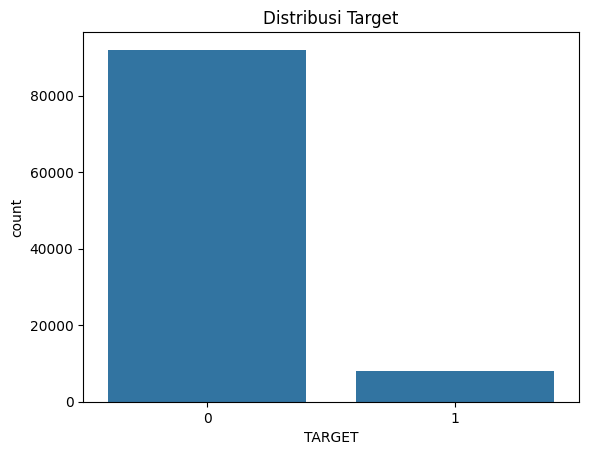

In [ ]:
# Visualisasi distribusi variabel TARGET
sns.countplot(x=df_HCDR_application_train_sample["TARGET"])
plt.title("Distribusi Target")
plt.show()

**VISUALISASI DISTRIBUSI LOAN AMOUNT**

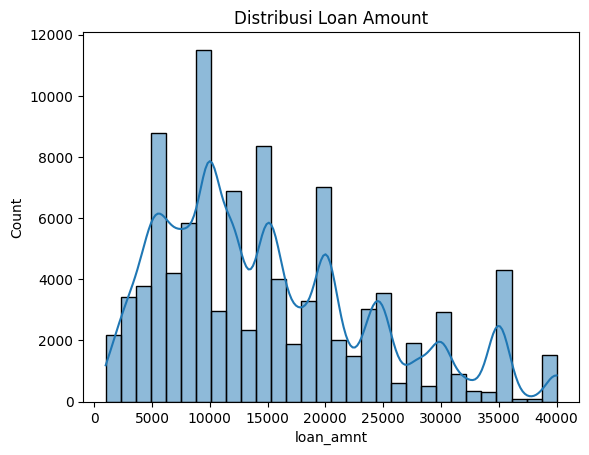

In [ ]:
sns.histplot(df_LCLD_accepted_sample["loan_amnt"], bins=30, kde=True)
plt.title("Distribusi Loan Amount")
plt.show()

**VISUALISASI DISTRIBUSI FITUR NUMERIK**

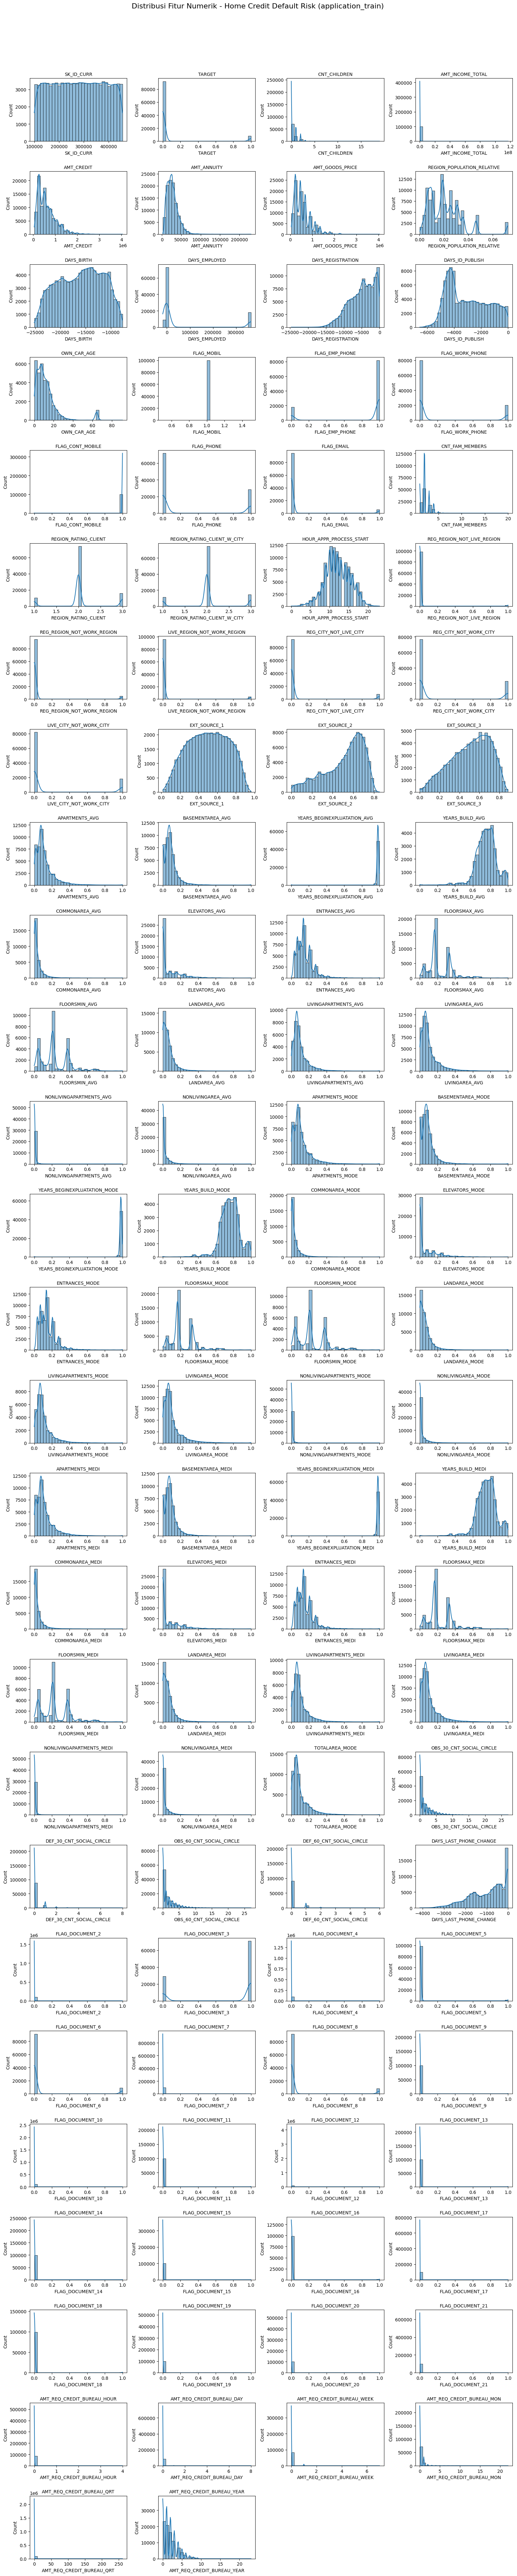

In [ ]:
def plot_numerical_distribution(df, title):
    num_cols = df.select_dtypes(include=['number']).columns  # Ambil hanya fitur numerik
    n_cols = 4  # Tentukan jumlah kolom dalam grid
    n_rows = int(np.ceil(len(num_cols) / n_cols))  # Hitung jumlah baris secara dinamis

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))  # Atur ukuran grid
    fig.suptitle(title, fontsize=16)

    axes = axes.flatten()  # Ubah grid axes jadi list

    for i, col in enumerate(num_cols):
        sns.histplot(df[col], bins=30, kde=True, ax=axes[i])  # Tambahkan KDE untuk distribusi
        axes[i].set_title(col, fontsize=10)

    # Hapus subplot kosong jika ada
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Hindari tumpang tindih dengan judul
    plt.show()

plot_numerical_distribution(df_HCDR_application_train_sample, "Distribusi Fitur Numerik - Home Credit Default Risk (application_train)")

**VISUALISASI DISTRIBUSI FITUR KATEGORIKAL**

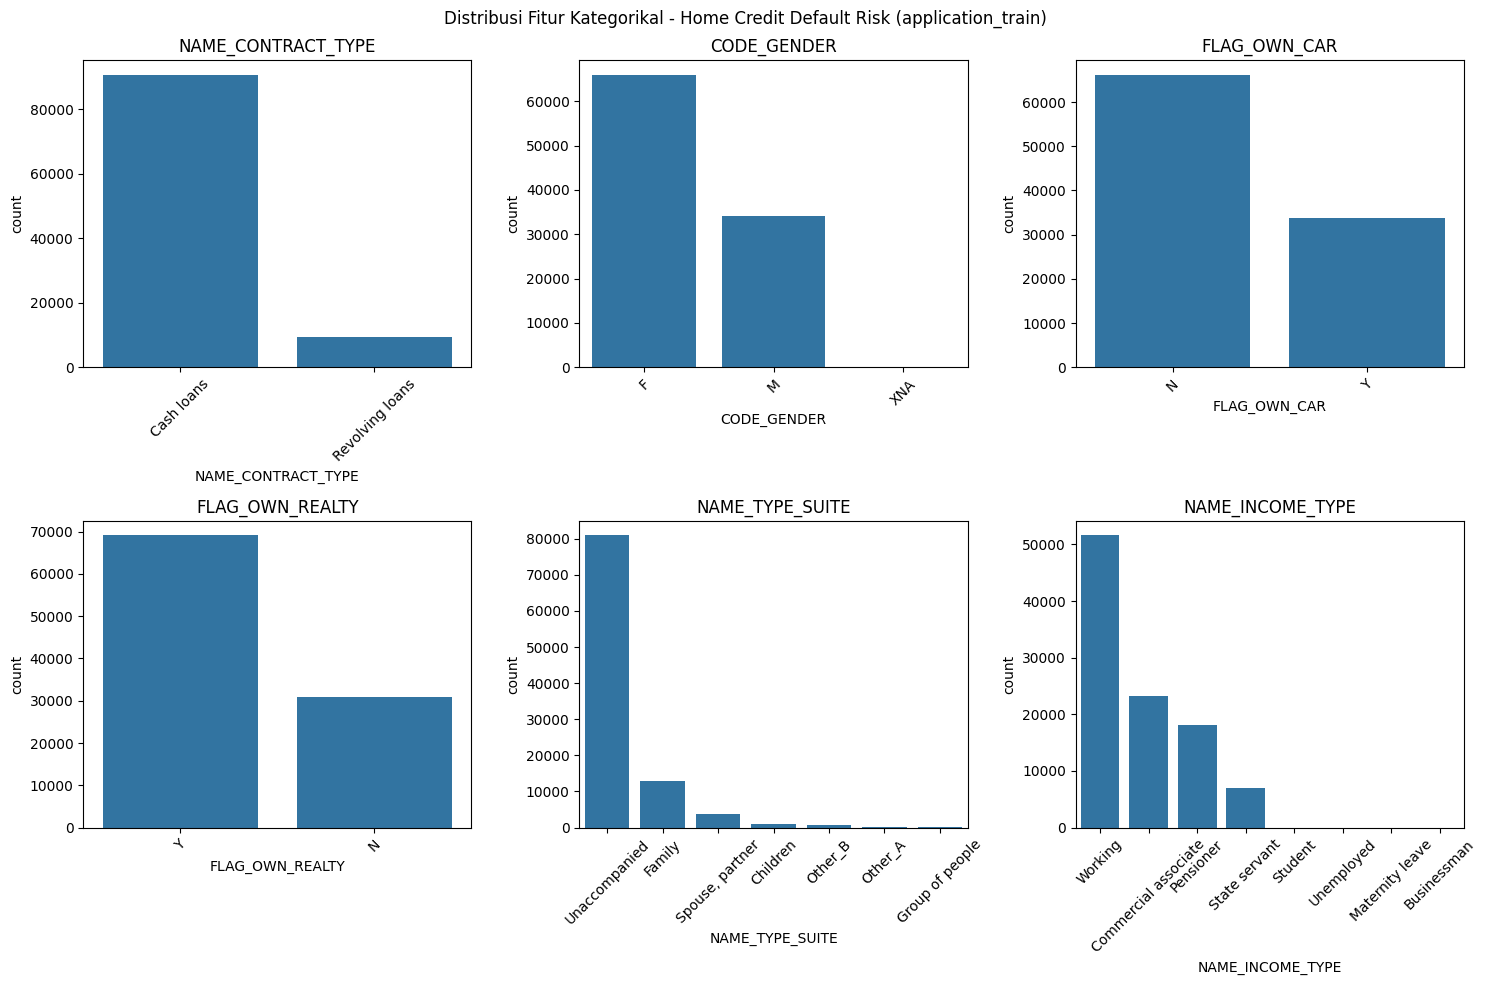

In [ ]:
def plot_categorical_distribution(df, title):
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()

    if len(cat_cols) == 0:
        print("⚠️ Tidak ada fitur kategorikal dalam dataset.")
        return

    plt.figure(figsize=(15, 10))
    for i, col in enumerate(cat_cols[:6]):  # Tampilkan 6 fitur pertama
        plt.subplot(2, 3, i + 1)
        sns.countplot(x=df[col], order=df[col].value_counts().index)
        plt.xticks(rotation=45)
        plt.title(col)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_categorical_distribution(df_HCDR_application_train_sample, "Distribusi Fitur Kategorikal - Home Credit Default Risk (application_train)")

**PISAHKAN FITUR KATEGORIKAL & NUMERIK**

In [ ]:
# Pisahkan fitur kategorikal & numerik
categorical_features = df_HCDR_application_train_sample.select_dtypes(include=['object']).columns
numerical_features = df_HCDR_application_train_sample.select_dtypes(include=['number']).columns

print("Fitur Kategorikal:", categorical_features.tolist())
print("Fitur Numerik:", numerical_features.tolist())

Fitur Kategorikal: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']
Fitur Numerik: ['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_S

**HEATMAP KORELASI ANTAR FITUR NUMERIK**

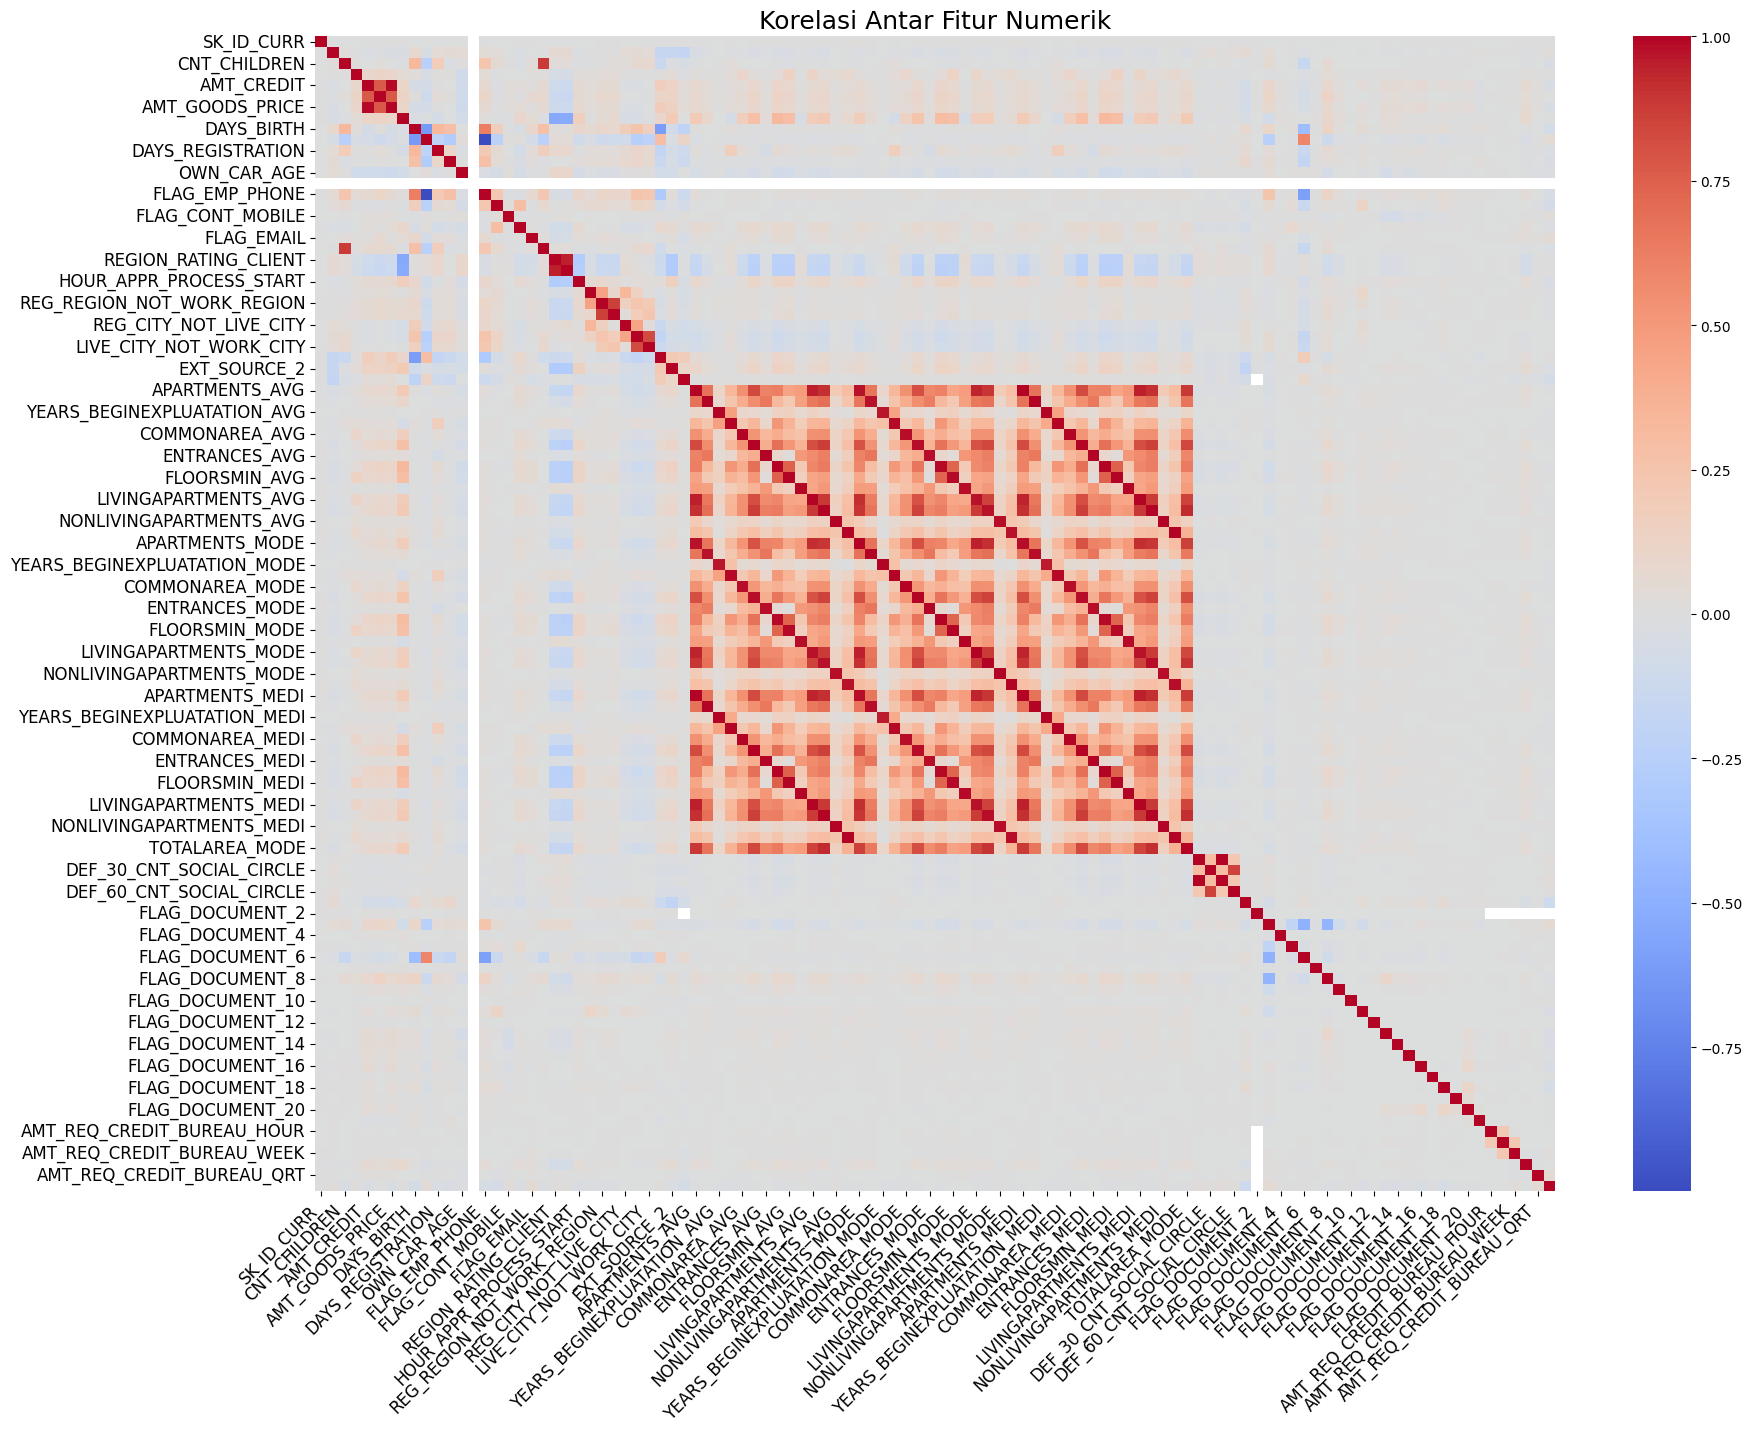

In [ ]:
plt.figure(figsize=(20, 15))  # Perbesar ukuran heatmap
sns.heatmap(df_HCDR_application_train_sample[numerical_features].corr(),
            annot=False, cmap='coolwarm')  # Hilangkan anotasi angka agar lebih rapi
plt.title("Korelasi Antar Fitur Numerik", fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=12)  # Rotasi label sumbu X
plt.yticks(fontsize=12)  # Atur ukuran label sumbu Y
plt.show()

**IDENTIFIKASI FITUR DENGAN KORELASI TINGGI**

In [ ]:
corr_matrix = df_HCDR_application_train_sample[numerical_features].corr().abs()
high_corr_features = [(col1, col2, corr_matrix.loc[col1, col2])
                      for col1 in corr_matrix.columns
                      for col2 in corr_matrix.columns
                      if col1 != col2 and corr_matrix.loc[col1, col2] > 0.8]
high_corr_features = sorted(high_corr_features, key=lambda x: -x[2])
high_corr_features[:10]  # Menampilkan 10 pasangan fitur dengan korelasi tertinggi

[('DAYS_EMPLOYED', 'FLAG_EMP_PHONE', np.float64(0.9997525638842981)),
 ('FLAG_EMP_PHONE', 'DAYS_EMPLOYED', np.float64(0.9997525638842981)),
 ('OBS_30_CNT_SOCIAL_CIRCLE',
  'OBS_60_CNT_SOCIAL_CIRCLE',
  np.float64(0.9983754665266128)),
 ('OBS_60_CNT_SOCIAL_CIRCLE',
  'OBS_30_CNT_SOCIAL_CIRCLE',
  np.float64(0.9983754665266128)),
 ('LIVINGAPARTMENTS_AVG',
  'LIVINGAPARTMENTS_MEDI',
  np.float64(0.9982692651322937)),
 ('LIVINGAPARTMENTS_MEDI',
  'LIVINGAPARTMENTS_AVG',
  np.float64(0.9982692651322937)),
 ('YEARS_BUILD_AVG', 'YEARS_BUILD_MEDI', np.float64(0.9982040023553342)),
 ('YEARS_BUILD_MEDI', 'YEARS_BUILD_AVG', np.float64(0.9982040023553342)),
 ('COMMONAREA_AVG', 'COMMONAREA_MEDI', np.float64(0.9981915727463264)),
 ('COMMONAREA_MEDI', 'COMMONAREA_AVG', np.float64(0.9981915727463264))]

**VISUALISASI BOXPLOT**

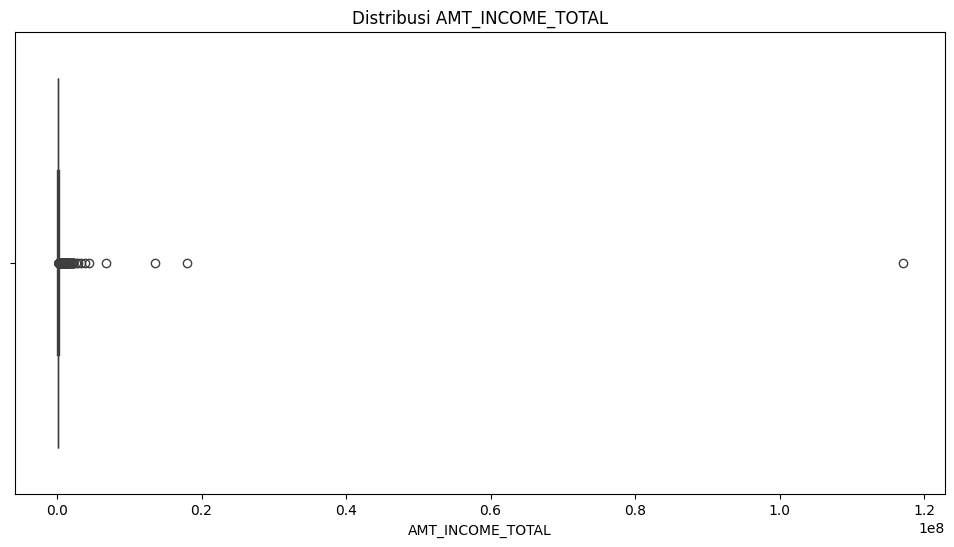

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df_HCDR_application_train_sample['AMT_INCOME_TOTAL'])
plt.title("Distribusi AMT_INCOME_TOTAL")
plt.show()

**VISUALISASI DISTRIBUSI BEBERAPA FITUR KATEGORIKAL**

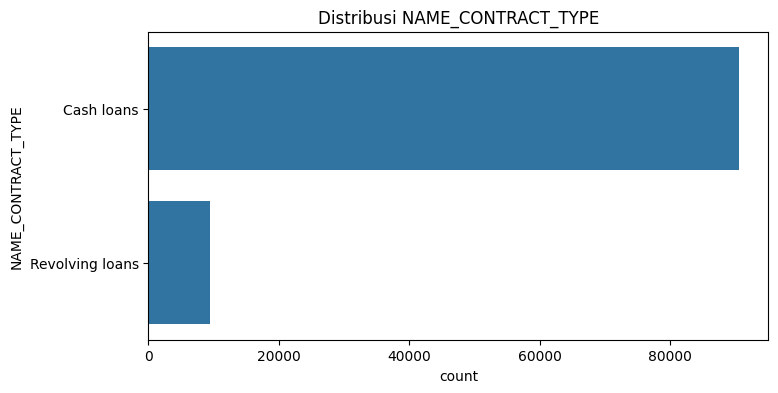

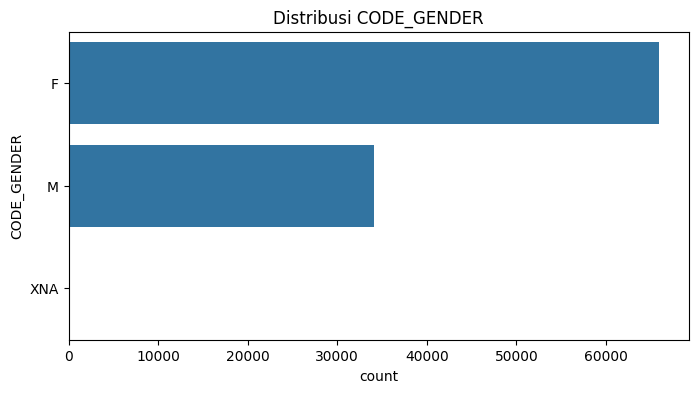

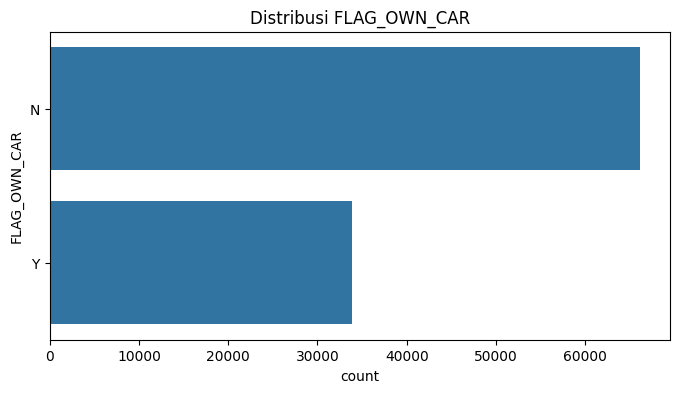

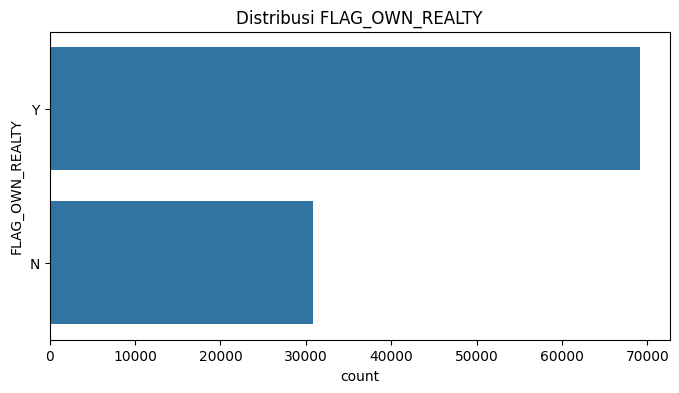

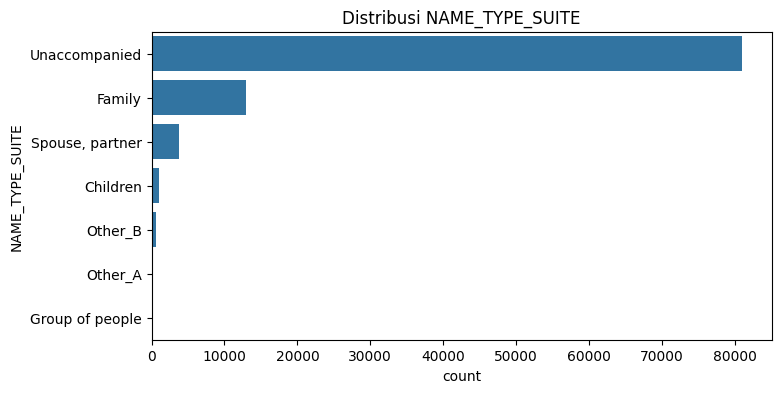

In [ ]:
categorical_features = df_HCDR_application_train_sample.select_dtypes(include=['object']).columns
for col in categorical_features[:5]:  # Ambil beberapa contoh
    plt.figure(figsize=(8, 4))
    sns.countplot(y=df_HCDR_application_train_sample[col], order=df_HCDR_application_train_sample[col].value_counts().index)
    plt.title(f"Distribusi {col}")
    plt.show()

# **2) Penanganan Data yang Hilang dan Pembersihan Data**

In [ ]:
# Cek nilai yang hilang pada Lending Club Loan Data (accepted_2007_to_2018Q4)
missing_LCLD_accepted = df_LCLD_accepted_sample.isnull().sum().sort_values(ascending=False)
print("\nMissing Values - Lending Club Loan Data (accepted_2007_to_2018Q4):")
print(missing_LCLD_accepted[missing_LCLD_accepted > 0])

# Cek nilai yang hilang pada Lending Club Loan Data (rejected_2007_to_2018Q4)
missing_LCLD_rejected = df_LCLD_rejected_sample.isnull().sum().sort_values(ascending=False)
print("\nMissing Values - Lending Club Loan Data (rejected_2007_to_2018Q4):")
print(missing_LCLD_rejected[missing_LCLD_rejected > 0])

# Cek nilai yang hilang pada Home Credit Default Risk (application_train)
missing_HCDR = df_HCDR_application_train_sample.isnull().sum().sort_values(ascending=False)
print("\nMissing Values - Home Credit Default Risk (application_train):")
print(missing_HCDR[missing_HCDR > 0])

# Persentase nilai yang hilang pada Lending Club Loan Data (accepted_2007_to_2018Q4)
print("\nPersentase missing values - Lending Club Loan Data (accepted_2007_to_2018Q4):")
print(df_LCLD_accepted_sample.isnull().sum() / len(df_LCLD_accepted_sample) * 100)

# Persentase nilai yang hilang pada Lending Club Loan Data (rejected_2007_to_2018Q4)
print("\nPersentase missing values - Lending Club Loan Data (rejected_2007_to_2018Q4):")
print(df_LCLD_rejected_sample.isnull().sum() / len(df_LCLD_rejected_sample) * 100)

# Persentase nilai yang hilang pada Home Credit Default Risk (application_train)
print("\nPersentase missing values - Home Credit Default Risk (application_train):")
print(df_HCDR_application_train_sample.isnull().sum() / len(df_HCDR_application_train_sample) * 100)



Missing Values - Lending Club Loan Data (accepted_2007_to_2018Q4):
member_id                                     100000
orig_projected_additional_accrued_interest     99617
hardship_reason                                99510
hardship_payoff_balance_amount                 99510
hardship_last_payment_amount                   99510
                                               ...  
total_rec_int                                      4
fico_range_high                                    4
disbursement_method                                4
hardship_flag                                      4
debt_settlement_flag                               4
Length: 150, dtype: int64

Missing Values - Lending Club Loan Data (rejected_2007_to_2018Q4):
Risk_Score           66586
Employment Length     3452
Loan Title               5
Policy Code              3
dtype: int64

Missing Values - Home Credit Default Risk (application_train):
COMMONAREA_AVG              69912
COMMONAREA_MODE             69912
CO

In [ ]:
# Mengisi missing values pada Lending Club Loan Data (accepted_2007_to_2018Q4)
# Mengisi missing values numerik dengan rata-rata
numeric_columns_LCLD_accepted = df_LCLD_accepted_sample.select_dtypes(include='number').columns
df_LCLD_accepted_sample[numeric_columns_LCLD_accepted] = df_LCLD_accepted_sample[numeric_columns_LCLD_accepted].fillna(df_LCLD_accepted_sample[numeric_columns_LCLD_accepted].mean())

# Mengisi missing values pada kolom kategorikal dengan modus
categorical_columns_LCLD_accepted = df_LCLD_accepted_sample.select_dtypes(include='object').columns
for col in categorical_columns_LCLD_accepted:
    # Mengonversi kolom ke tipe string jika campuran tipe data ada di kolom tersebut
    df_LCLD_accepted_sample[col] = df_LCLD_accepted_sample[col].astype(str)
    df_LCLD_accepted_sample[col] = df_LCLD_accepted_sample[col].fillna(df_LCLD_accepted_sample[col].mode().iloc[0])

# Mengisi missing values pada Lending Club Loan Data (rejected_2007_to_2018Q4)
# Mengisi missing values numerik dengan rata-rata
numeric_columns_LCLD_rejected = df_LCLD_rejected_sample.select_dtypes(include='number').columns
df_LCLD_rejected_sample[numeric_columns_LCLD_rejected] = df_LCLD_rejected_sample[numeric_columns_LCLD_rejected].fillna(df_LCLD_rejected_sample[numeric_columns_LCLD_rejected].mean())

# Mengisi missing values pada kolom kategorikal dengan modus
categorical_columns_LCLD_rejected = df_LCLD_rejected_sample.select_dtypes(include='object').columns
for col in categorical_columns_LCLD_rejected:
    # Mengonversi kolom ke tipe string jika campuran tipe data ada di kolom tersebut
    df_LCLD_rejected_sample[col] = df_LCLD_rejected_sample[col].astype(str)
    df_LCLD_rejected_sample[col] = df_LCLD_rejected_sample[col].fillna(df_LCLD_rejected_sample[col].mode().iloc[0])

# Mengisi missing values pada Home Credit Default Risk (application_train)
# Mengisi missing values numerik dengan rata-rata
numeric_columns_HCDR = df_HCDR_application_train_sample.select_dtypes(include='number').columns
df_HCDR_application_train_sample[numeric_columns_HCDR] = df_HCDR_application_train_sample[numeric_columns_HCDR].fillna(df_HCDR_application_train_sample[numeric_columns_HCDR].mean())

# Mengisi missing values pada kolom kategorikal dengan modus
categorical_columns_HCDR = df_HCDR_application_train_sample.select_dtypes(include='object').columns
for col in categorical_columns_HCDR:
    # Mengonversi kolom ke tipe string jika campuran tipe data ada di kolom tersebut
    df_HCDR_application_train_sample[col] = df_HCDR_application_train_sample[col].astype(str)
    df_HCDR_application_train_sample[col] = df_HCDR_application_train_sample[col].fillna(df_HCDR_application_train_sample[col].mode().iloc[0])

# Menampilkan data setelah handling missing values
print("\nData setelah menangani missing values (Lending Club Loan Data - accepted):")
print(df_LCLD_accepted_sample.shape)
print("\nData setelah menangani missing values (Lending Club Loan Data - rejected):")
print(df_LCLD_rejected_sample.shape)
print("\nData setelah menangani missing values (Home Credit Default Risk - application_train):")
print(df_HCDR_application_train_sample.shape)


Data setelah menangani missing values (Lending Club Loan Data - accepted):
(100000, 151)

Data setelah menangani missing values (Lending Club Loan Data - rejected):
(100000, 9)

Data setelah menangani missing values (Home Credit Default Risk - application_train):
(100000, 122)


# **3) Transformasi dan Rekayasa Fitur**

Transformasi
Lending Club Loan Data - Accepted

In [ ]:
pd.set_option('display.max_columns', None)

# Tampilkan 5 data pertama SEBELUM transformasi
print("DATA SEBELUM TRANSFORMASI\n")
print(df_LCLD_accepted_sample.head())

# ==================== Binary Encoding ====================
binary_cols = ['pymnt_plan', 'hardship_flag']
for col in binary_cols:
    if col in df_LCLD_accepted_sample.columns:
        df_LCLD_accepted_sample[col] = df_LCLD_accepted_sample[col].map({'y': 1, 'n': 0})

# ==================== Ordinal Encoding ====================
grade_order = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
if 'grade' in df_LCLD_accepted_sample.columns:
    df_LCLD_accepted_sample['grade'] = df_LCLD_accepted_sample['grade'].map(grade_order)

if 'sub_grade' in df_LCLD_accepted_sample.columns:
    sub_grade_order = sorted(df_LCLD_accepted_sample['sub_grade'].dropna().unique())
    sub_grade_mapping = {grade: idx for idx, grade in enumerate(sub_grade_order)}
    df_LCLD_accepted_sample['sub_grade'] = df_LCLD_accepted_sample['sub_grade'].map(sub_grade_mapping)

emp_length_mapping = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10
}
if 'emp_length' in df_LCLD_accepted_sample.columns:
    df_LCLD_accepted_sample['emp_length'] = df_LCLD_accepted_sample['emp_length'].map(emp_length_mapping)

# ==================== One-hot Encoding ====================
one_hot_cols = ['verification_status', 'home_ownership', 'loan_status']
df_LCLD_accepted_sample = pd.get_dummies(
    df_LCLD_accepted_sample,
    columns=[col for col in one_hot_cols if col in df_LCLD_accepted_sample.columns],
    drop_first=True
)

# ==================== Frequency Encoding ====================
for col in ['addr_state', 'next_pymnt_d']:
    if col in df_LCLD_accepted_sample.columns:
        freq = df_LCLD_accepted_sample[col].value_counts() / len(df_LCLD_accepted_sample)
        df_LCLD_accepted_sample[col] = df_LCLD_accepted_sample[col].map(freq)

# Tampilkan 5 data pertama SETELAH transformasi
print("\nDATA SETELAH TRANSFORMASI\n")
print(df_LCLD_accepted_sample.head())

DATA SEBELUM TRANSFORMASI

          id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0   39651438        NaN    32000.0      32000.0          32000.0   60 months   
1   16411620        NaN     9600.0       9600.0           9600.0   36 months   
2   45122316        NaN     4000.0       4000.0           4000.0   36 months   
3  125356772        NaN     6025.0       6025.0           6025.0   36 months   
4  128490686        NaN    25000.0      25000.0          25000.0   60 months   

   int_rate  installment grade sub_grade        emp_title emp_length  \
0     10.49       687.65     B        B3   Public Service  10+ years   
1     12.99       323.42     C        C1              nan        nan   
2      6.68       122.93     A        A3   System Analyst    4 years   
3     10.91       197.00     B        B4  Admin assistant  10+ years   
4     26.30       752.96     E        E5     Coordinator   10+ years   

  home_ownership  annual_inc verification_status   issue_d 

Transformasi Home Credit Default Risk - Application Train

In [ ]:
# Tampilkan data sebelum transformasi
print("DATA SEBELUM TRANSFORMASI:\n")
print(df_HCDR_application_train_sample.head())

# ==================== Binary Encoding ====================
binary_cols = ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'EMERGENCYSTATE_MODE']
for col in binary_cols:
    if col in df_HCDR_application_train_sample.columns:
        df_HCDR_application_train_sample[col] = df_HCDR_application_train_sample[col].map({'Y': 1, 'N': 0})

# ==================== Ordinal Encoding ====================
education_order = {
    'Lower secondary': 0,
    'Secondary / secondary special': 1,
    'Incomplete higher': 2,
    'Higher education': 3,
    'Academic degree': 4
}
if 'NAME_EDUCATION_TYPE' in df_HCDR_application_train_sample.columns:
    df_HCDR_application_train_sample['NAME_EDUCATION_TYPE'] = df_HCDR_application_train_sample['NAME_EDUCATION_TYPE'].map(education_order)

# ==================== One-hot Encoding ====================
one_hot_cols = [
    'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'HOUSETYPE_MODE', 'FONDKAPREMONT_MODE',
    'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'NAME_TYPE_SUITE',
    'WEEKDAY_APPR_PROCESS_START', 'WALLSMATERIAL_MODE', 'NAME_INCOME_TYPE'
]
df_HCDR_application_train_sample = pd.get_dummies(
    df_HCDR_application_train_sample,
    columns=[col for col in one_hot_cols if col in df_HCDR_application_train_sample.columns],
    drop_first=True
)

# ==================== Frequency Encoding ====================
for col in ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE']:
    if col in df_HCDR_application_train_sample.columns:
        freq = df_HCDR_application_train_sample[col].value_counts() / len(df_HCDR_application_train_sample)
        df_HCDR_application_train_sample[col] = df_HCDR_application_train_sample[col].map(freq)

# Tampilkan data setelah transformasi
print("\nDATA SETELAH TRANSFORMASI:\n")
pd.set_option('display.max_columns', None)  # Agar semua kolom tampil
print(df_HCDR_application_train_sample.head())


DATA SEBELUM TRANSFORMASI:

   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      384575       0         Cash loans           M            Y   
1      214010       0         Cash loans           F            Y   
2      142232       0         Cash loans           F            Y   
3      389171       0         Cash loans           F            N   
4      283617       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               N             2          207000.0    465457.5      52641.0   
1               Y             0          247500.0   1281712.5      48946.5   
2               N             0          202500.0    495000.0      39109.5   
3               Y             0          247500.0    254700.0      24939.0   
4               Y             0          112500.0    308133.0      15862.5   

   AMT_GOODS_PRICE NAME_TYPE_SUITE      NAME_INCOME_TYPE  \
0         418500.0   Unaccom

Normalisasi/Standarisasi Fitur Numerik

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Pilih salah satu scaler
scaler = StandardScaler()
# scaler = MinMaxScaler()

# ==================== HCDR Dataset ====================
print("\n=== DATA HCDR SEBELUM NORMALISASI/STANDARISASI ===\n")
print(df_HCDR_application_train_sample.head())

# Simpan data asli numerik untuk perbandingan jika mau
hcdr_numeric_cols = df_HCDR_application_train_sample.select_dtypes(include=['float64', 'int64']).columns
df_HCDR_application_train_sample[hcdr_numeric_cols] = scaler.fit_transform(df_HCDR_application_train_sample[hcdr_numeric_cols])

print("\n=== DATA HCDR SETELAH NORMALISASI/STANDARISASI ===\n")
pd.set_option('display.max_columns', None)
print(df_HCDR_application_train_sample.head())

# ==================== LCLD Dataset ====================
print("\n=== DATA LCLD SEBELUM NORMALISASI/STANDARISASI ===\n")
print(df_LCLD_accepted_sample.head())

lcld_numeric_cols = df_LCLD_accepted_sample.select_dtypes(include=['float64', 'int64']).columns
df_LCLD_accepted_sample[lcld_numeric_cols] = scaler.fit_transform(df_LCLD_accepted_sample[lcld_numeric_cols])

print("\n=== DATA LCLD SETELAH NORMALISASI/STANDARISASI ===\n")
print(df_LCLD_accepted_sample.head())

print("\nNormalisasi/Standarisasi selesai untuk kedua dataset.")


=== DATA HCDR SEBELUM NORMALISASI/STANDARISASI ===

   SK_ID_CURR  TARGET  FLAG_OWN_CAR  FLAG_OWN_REALTY  CNT_CHILDREN  \
0      384575       0             1                0             2   
1      214010       0             1                1             0   
2      142232       0             1                0             0   
3      389171       0             0                1             0   
4      283617       0             0                1             0   

   AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE  \
0          207000.0    465457.5      52641.0         418500.0   
1          247500.0   1281712.5      48946.5        1179000.0   
2          202500.0    495000.0      39109.5         495000.0   
3          247500.0    254700.0      24939.0         225000.0   
4          112500.0    308133.0      15862.5         234000.0   

   NAME_EDUCATION_TYPE  REGION_POPULATION_RELATIVE  DAYS_BIRTH  DAYS_EMPLOYED  \
0                    1                    0.009630    

/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count



=== DATA HCDR SETELAH NORMALISASI/STANDARISASI ===

   SK_ID_CURR    TARGET  FLAG_OWN_CAR  FLAG_OWN_REALTY  CNT_CHILDREN  \
0    1.037713 -0.295084      1.397494        -1.497512      2.178788   
1   -0.624764 -0.295084      1.397494         0.667774     -0.574414   
2   -1.324375 -0.295084      1.397494        -1.497512     -0.574414   
3    1.082510 -0.295084     -0.715567         0.667774     -0.574414   
4    0.053688 -0.295084     -0.715567         0.667774     -0.574414   

   AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE  \
0          0.096333   -0.330650     1.768382        -0.323415   
1          0.200404    1.700736     1.512589         1.739313   
2          0.084769   -0.257128     0.831513        -0.115921   
3          0.200404   -0.855155    -0.149597        -0.848251   
4         -0.146501   -0.722178    -0.778018        -0.823840   

   NAME_EDUCATION_TYPE  REGION_POPULATION_RELATIVE  DAYS_BIRTH  DAYS_EMPLOYED  \
0            -0.579815                   -

/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count



=== DATA LCLD SETELAH NORMALISASI/STANDARISASI ===

          id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0   39651438        NaN   1.836116     1.836922         1.838012   60 months   
1   16411620        NaN  -0.594856    -0.594433        -0.592432   36 months   
2   45122316        NaN  -1.202599    -1.202272        -1.200043   36 months   
3  125356772        NaN  -0.982835    -0.982473        -0.980326   36 months   
4  128490686        NaN   1.076437     1.077124         1.078499   60 months   

   int_rate  installment     grade  sub_grade        emp_title  emp_length  \
0 -0.544421     0.898678 -0.534507  -0.526100   Public Service    1.092866   
1 -0.027750    -0.460238  0.259335  -0.050995              nan         NaN   
2 -1.331827    -1.208251 -1.328349  -1.317943   System Analyst   -0.519945   
3 -0.457620    -0.931901 -0.534507  -0.367732  Admin assistant    1.092866   
4  2.723004     1.142344  1.847018   2.166165     Coordinator     1.092866  

Fitur Baru Pada Masing-Masing Dataset

In [ ]:
# ==================== HCDR Dataset - Sebelum Penambahan Fitur Baru ====================
print("\n=== DATA HCDR SEBELUM FITUR BARU ===\n")
print(df_HCDR_application_train_sample.head())

# Buat fitur baru INCOME_CREDIT_RATIO
if 'AMT_INCOME_TOTAL' in df_HCDR_application_train_sample.columns and 'AMT_CREDIT' in df_HCDR_application_train_sample.columns:
    df_HCDR_application_train_sample['INCOME_CREDIT_RATIO'] = (
        df_HCDR_application_train_sample['AMT_INCOME_TOTAL'] / (df_HCDR_application_train_sample['AMT_CREDIT'] + 1e-6)
    )

# ==================== HCDR Dataset - Setelah Penambahan Fitur Baru ====================
print("\n=== DATA HCDR SETELAH FITUR BARU ===\n")
pd.set_option('display.max_columns', None)
print(df_HCDR_application_train_sample[['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'INCOME_CREDIT_RATIO']].head())

# ==================== LCLD Dataset - Sebelum Penambahan Fitur Baru ====================
print("\n=== DATA LCLD SEBELUM FITUR BARU ===\n")
print(df_LCLD_accepted_sample.head())

# Buat fitur baru INSTALLMENT_RATIO
if 'installment' in df_LCLD_accepted_sample.columns and 'annual_inc' in df_LCLD_accepted_sample.columns:
    df_LCLD_accepted_sample['INSTALLMENT_RATIO'] = (
        df_LCLD_accepted_sample['installment'] / (df_LCLD_accepted_sample['annual_inc'] + 1e-6)
    )

# ==================== LCLD Dataset - Setelah Penambahan Fitur Baru ====================
print("\n=== DATA LCLD SETELAH FITUR BARU ===\n")
print(df_LCLD_accepted_sample[['installment', 'annual_inc', 'INSTALLMENT_RATIO']].head())



=== DATA HCDR SEBELUM FITUR BARU ===

   SK_ID_CURR    TARGET  FLAG_OWN_CAR  FLAG_OWN_REALTY  CNT_CHILDREN  \
0    1.037713 -0.295084      1.397494        -1.497512      2.178788   
1   -0.624764 -0.295084      1.397494         0.667774     -0.574414   
2   -1.324375 -0.295084      1.397494        -1.497512     -0.574414   
3    1.082510 -0.295084     -0.715567         0.667774     -0.574414   
4    0.053688 -0.295084     -0.715567         0.667774     -0.574414   

   AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE  \
0          0.096333   -0.330650     1.768382        -0.323415   
1          0.200404    1.700736     1.512589         1.739313   
2          0.084769   -0.257128     0.831513        -0.115921   
3          0.200404   -0.855155    -0.149597        -0.848251   
4         -0.146501   -0.722178    -0.778018        -0.823840   

   NAME_EDUCATION_TYPE  REGION_POPULATION_RELATIVE  DAYS_BIRTH  DAYS_EMPLOYED  \
0            -0.579815                   -0.812378    0.

<ipython-input-23-b5ad3bac1769>:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_HCDR_application_train_sample['INCOME_CREDIT_RATIO'] = (
<ipython-input-23-b5ad3bac1769>:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_LCLD_accepted_sample['INSTALLMENT_RATIO'] = (


# **4) Analisis Ketidakseimbangan Kelas dan Perbandingan Metode Prapemrosesan**

LCLD Accepted Variables
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_j

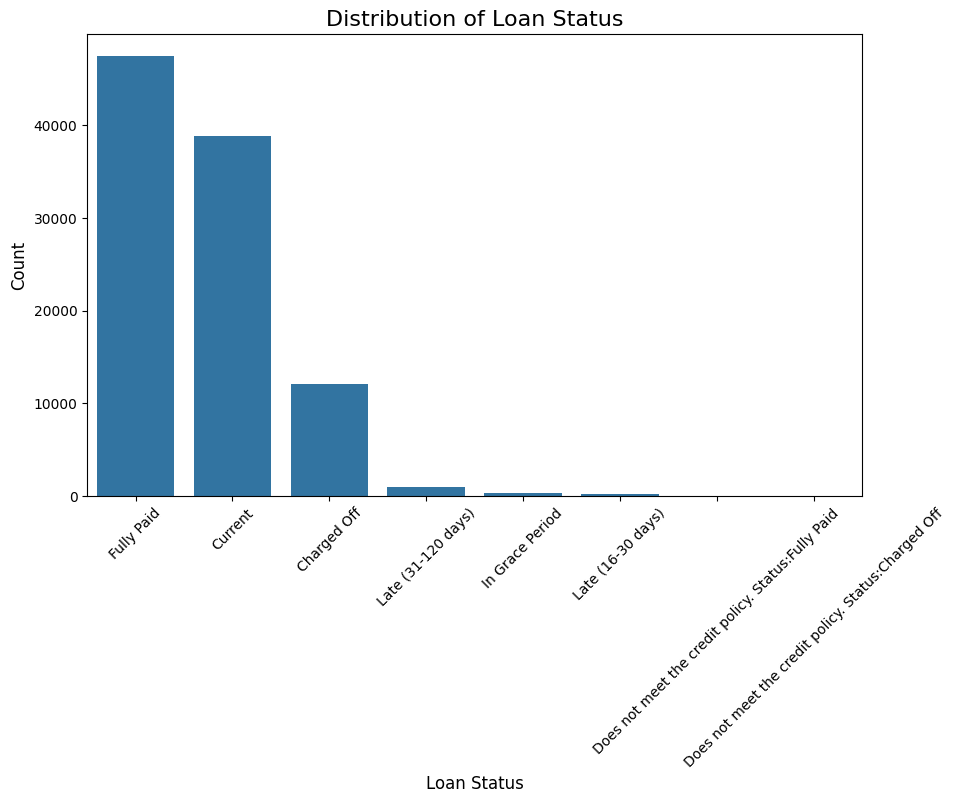


LCLD Rejected Variables
['Amount Requested', 'Application Date', 'Loan Title', 'Risk_Score', 'Debt-To-Income Ratio', 'Zip Code', 'State', 'Employment Length', 'Policy Code']


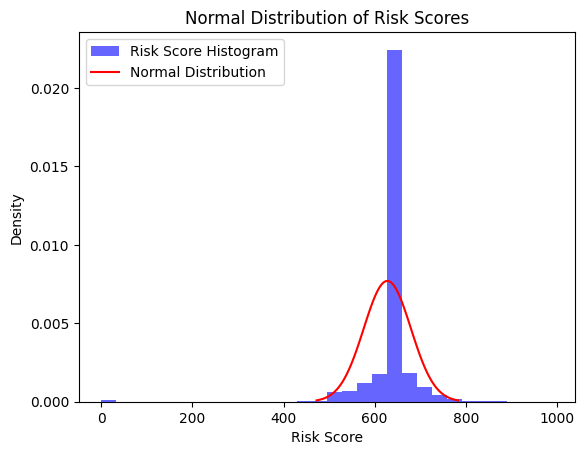


HCDR Variables
['SK_ID_CURR', 'TARGET', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_EDUCATION_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGA

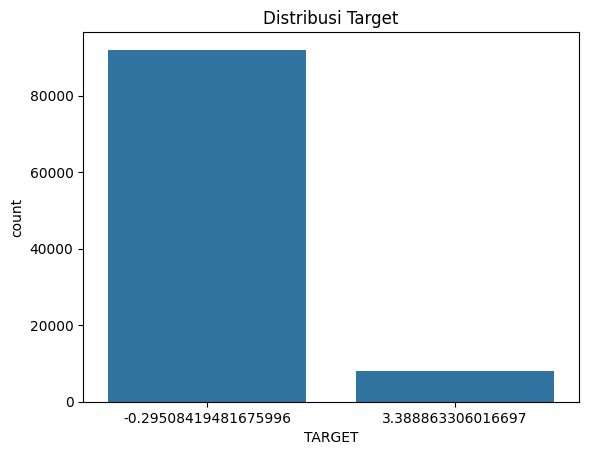

In [ ]:
#Distribusi kelas dalam variabel target
print('LCLD Accepted Variables')
print(df_LCLD_accepted_sample_raw.columns.tolist()) #target variabel berupa loan status
print(df_LCLD_accepted_sample_raw['loan_status'].unique()) #['Current' 'Fully Paid' 'Charged Off' 'Late (31-120 days)' 'Late (16-30 days)' 'In Grace Period' 'Does not meet the credit policy. Status:Fully Paid' 'Does not meet the credit policy. Status:Charged Off']
plt.figure(figsize=(10, 6))
# Create a countplot to visualize the distribution of loan_status
sns.countplot(data=df_LCLD_accepted_sample_raw, x='loan_status', order=df_LCLD_accepted_sample_raw['loan_status'].value_counts().index)
# Add labels and title
plt.title('Distribution of Loan Status', fontsize=16)
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
# Show the plot
plt.show()


print('\nLCLD Rejected Variables')
print(df_LCLD_rejected_sample_raw.columns.tolist()) #target variabel berupa risk_score
from scipy.stats import norm
risk_scores = df_LCLD_rejected_sample['Risk_Score']
# Calculate mean and standard deviation of Risk_Score
mean = risk_scores.mean()
std_dev = risk_scores.std()
# Generate x values for the normal distribution curve
x = np.linspace(mean - 3 * std_dev, mean + 3 * std_dev, 100)
# Calculate y values for the normal distribution curve (PDF)
y = norm.pdf(x, mean, std_dev)
# Plot histogram of Risk_Score with density=True to normalize
plt.hist(risk_scores, bins=30, density=True, alpha=0.6, color='blue', label='Risk Score Histogram')
plt.plot(x, y, color='red', label='Normal Distribution')
plt.xlabel('Risk Score')
plt.ylabel('Density')
plt.title('Normal Distribution of Risk Scores')
plt.legend()
plt.show()

print('\nHCDR Variables')
print(df_HCDR_application_train_sample.columns.tolist()) #target variable berupa TARGET
print(df_HCDR_application_train_sample['TARGET'].unique()) #[0 1]
sns.countplot(x=df_HCDR_application_train_sample["TARGET"])
plt.title("Distribusi Target")
plt.show()

Dari analisis di atas,

LCLD Accepted memiliki distribusi kelas ketegorikal sebanyak 7 dengan distribusi terbanyak oleh status Fully Paid, Current, dan Charged Off

LCLD Rejected memiliki distribusi kelas numerikal yang tersebar pada risk score 600

HCDR memiliki distribusi kelas kategorikal sebanyak 2 dengan distribusi 0 dan 1. Distribusi terbanyak dipegang oleh status 0

Apakah data memiliki ketidakseimbangan kelas?
LCLD Accepted dan Rejected terlihat memiliki distribusi persebaran yang baik, walaupun di Accepted tidak semua kategori terisi.

HCDR didominasi oleh sisi 0.

Penanganan ketidakseimbangan kelas pada HCDR

SMOTE (Synthetic Minority Oversampling Technique)

Random Oversampling (ROS)

Undersampling Kelas Mayoritas

Bobot Kelas (Class Weights)

TARGET
0    91990
1    91990
Name: count, dtype: int64


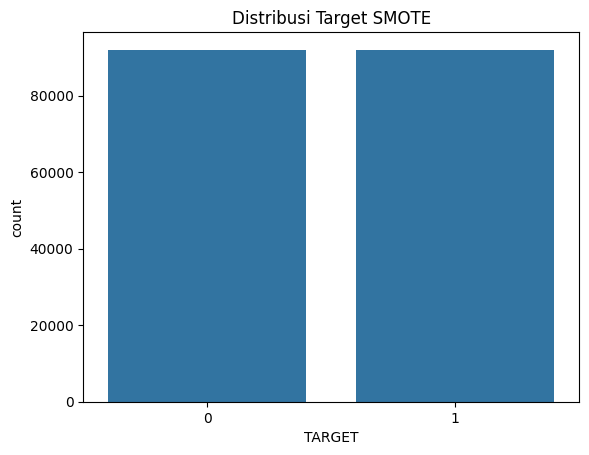

In [ ]:
#SMOTE

from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder

# Memisahkan fitur dan target
X = df_HCDR_application_train_sample_raw.drop('TARGET', axis=1)
y = df_HCDR_application_train_sample_raw['TARGET']
# Mengatasi nilai NaN dengan imputasi (misalnya, mengganti dengan rata-rata)

# Create a SimpleImputer instance for numeric features
num_imputer = SimpleImputer(strategy='mean')

# Create a SimpleImputer instance for categorical features
cat_imputer = SimpleImputer(strategy='most_frequent')

# Separate numeric and categorical features
num_features = X.select_dtypes(include=['number']).columns
cat_features = X.select_dtypes(include=['object']).columns

# Impute missing values separately for numeric and categorical features
X_num_imputed = num_imputer.fit_transform(X[num_features])
X_cat_imputed = cat_imputer.fit_transform(X[cat_features])

# Convert categorical features to numerical using OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore') # sparse=False for numpy array
X_cat_encoded = encoder.fit_transform(X_cat_imputed)

# Combine the imputed and encoded features back into a single DataFrame
X_imputed = np.concatenate([X_num_imputed, X_cat_encoded], axis=1)

# Menggunakan SMOTE untuk oversampling
smote = SMOTE(random_state=101)
X_resampled, y_resampled = smote.fit_resample(X_imputed, y)
# Membuat DataFrame baru dari hasil oversampling dengan nama kolom baru
df_oversampled_SMOTE = pd.DataFrame(X_resampled, columns=[f"feature_{i}" for i in range(X_resampled.shape[1])])
df_oversampled_SMOTE['TARGET'] = y_resampled
# Menampilkan informasi mengenai data oversampled
print(df_oversampled_SMOTE['TARGET'].value_counts())

sns.countplot(x=df_oversampled_SMOTE["TARGET"])
plt.title("Distribusi Target SMOTE")
plt.show()

Sebelum Oversampling:
TARGET
0    91990
1     8010
Name: count, dtype: int64

Setelah Oversampling:
TARGET
0    91990
1    91990
Name: count, dtype: int64


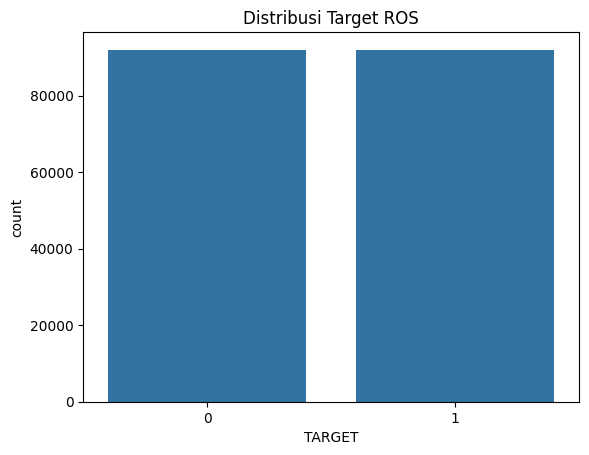

In [ ]:
#Random Oversampling (ROS)
from imblearn.over_sampling import RandomOverSampler

# Memisahkan fitur (X) dan target (y)
X = df_HCDR_application_train_sample_raw.drop(columns=['TARGET'])
y = df_HCDR_application_train_sample_raw['TARGET']

# Membuat instance RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Melakukan oversampling
X_resampled, y_resampled = ros.fit_resample(X, y)

# Menampilkan hasil setelah oversampling
print("Sebelum Oversampling:")
print(y.value_counts())

print("\nSetelah Oversampling:")
print(pd.Series(y_resampled).value_counts())

sns.countplot(x=y_resampled)
plt.title("Distribusi Target ROS")
plt.show()

TARGET
0    8010
1    8010
Name: count, dtype: int64


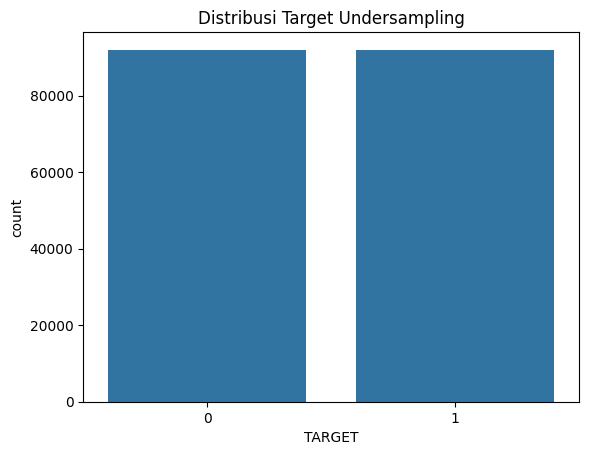

In [ ]:
#Undersampling Kelas Mayoritas
from sklearn.utils import resample

# Memisahkan kelas mayoritas dan minoritas
df_majority = df_HCDR_application_train_sample_raw[df_HCDR_application_train_sample_raw['TARGET'] == 0]
df_minority = df_HCDR_application_train_sample_raw[df_HCDR_application_train_sample_raw['TARGET'] == 1]

# Melakukan undersampling pada kelas mayoritas
df_majority_undersampled = resample(df_majority,
                                     replace=False,    # Tidak melakukan penggantian
                                     n_samples=len(df_minority),  # Mengambil jumlah yang sama dengan kelas minoritas
                                     random_state=42) # Untuk reproduktifitas

# Menggabungkan kembali dataset
df_undersampled = pd.concat([df_majority_undersampled, df_minority])

# Mengacak dataset akhir
df_undersampled = df_undersampled.sample(frac=1, random_state=42).reset_index(drop=True)

# Menampilkan informasi tentang dataset baru
print(df_undersampled['TARGET'].value_counts())

sns.countplot(x=df_oversampled_SMOTE["TARGET"])
plt.title("Distribusi Target Undersampling")
plt.show()

In [ ]:
#Class Weighting
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Assuming df_HCDR_application_train_sample is your dataset
# df_HCDR_application_train_sample = pd.read_csv('path_to_your_dataset.csv')

# Step 1: Separate features and target
X = df_HCDR_application_train_sample.drop(columns=['TARGET'])
y = df_HCDR_application_train_sample['TARGET']

# Step 2: Remove columns with all NaN values
X = X.dropna(axis=1, how='all')

# Step 3: Calculate class weights
# Ensure y is of integer type for classification
y = y.astype(int)  # Convert y to integer type
class_labels = y.unique()
class_weights = compute_class_weight(class_weight='balanced', classes=class_labels, y=y)
class_weight_dict = dict(zip(class_labels, class_weights))

print("Class Weights:", class_weight_dict)

# Step 4: Fill NaN values with the mean
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Step 5: Scale data for faster convergence
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Step 6: Train the model with imputed and scaled data
model = LogisticRegression(class_weight=class_weight_dict, max_iter=500)  # Increase max_iter
model.fit(X_scaled, y)

print("Model trained.\n")

from sklearn.metrics import classification_report, confusion_matrix

# Predict outcomes
y_pred = model.predict(X_scaled)

# Classification report
print("Classification Report:")
print(classification_report(y, y_pred))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y, y_pred))

Class Weights: {np.int64(0): np.float64(0.5435373410153278), np.int64(3): np.float64(6.242197253433209)}
Model trained.

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     91990
           3       0.16      0.68      0.26      8010

    accuracy                           0.69    100000
   macro avg       0.56      0.69      0.53    100000
weighted avg       0.90      0.69      0.76    100000

Confusion Matrix:
[[63251 28739]
 [ 2537  5473]]


Laporan ini menunjukkan bahwa model sangat baik dalam mengklasifikasikan kelas mayoritas (kelas 0) tetapi tidak dapat mendeteksi sama sekali kelas minoritas (kelas 3). Ini adalah masalah umum dalam dataset yang tidak seimbang dan menunjukkan perlunya pendekatan tambahan.

# **Kesimpulan**

Membandingkan hasil prapemrosesan dari kedua dataset dan menentukan dataset
mana yang lebih siap untuk proses prediksi?

Berdasarkan hasil eksplorasi data dan seluruh proses prapemrosesan yang telah dilakukan, dataset Home Credit Default Risk (HCDR) dinilai lebih layak dan cocok digunakan dalam proses prediksi risiko gagal bayar dibandingkan dataset Lending Club Loan Data (LCLD). Hal ini didasari oleh beberapa pertimbangan penting yang muncul dari kualitas data, kelengkapan informasi, dan kemudahan dalam penanganan data selama proses transformasi.

HCDR memiliki struktur data yang lebih teratur dan konsisten. Variabel target pada dataset ini jelas dan terukur, yaitu membedakan dengan baik antara nasabah yang gagal bayar dan yang tidak. Selain itu, fitur-fitur dalam HCDR menunjukkan relevansi yang kuat dengan target prediksi, seperti total pendapatan, jumlah kredit, usia, hingga kepemilikan properti dan kendaraan. Data numerik pada dataset ini juga lebih bersih dan mampu melewati proses normalisasi dengan baik, sehingga mempermudah proses modeling di tahap selanjutnya.

Berbeda dengan HCDR, dataset LCLD cenderung memiliki tantangan lebih besar dalam hal kualitas dan struktur data. Banyaknya variabel kategorikal yang bersifat bebas dan tidak terstruktur seperti 'emp_title' dan 'purpose' menyulitkan proses encoding. Selain itu, variabel target di LCLD berupa status pinjaman memiliki banyak kategori yang memerlukan penyederhanaan atau re-labeling sebelum dapat digunakan untuk model klasifikasi biner. Proses pembersihan data pada LCLD membutuhkan usaha lebih besar karena beberapa kolom penting mengandung missing values atau outlier yang cukup signifikan.

Dari sisi kelengkapan informasi, HCDR juga menawarkan fitur-fitur yang lebih variatif dan mendalam terkait kondisi sosial ekonomi nasabah, seperti tingkat pendidikan, tipe hunian, dan jenis pekerjaan, yang secara logis dapat berpengaruh terhadap kemampuan membayar pinjaman. Keberagaman fitur ini membuka peluang lebih besar dalam rekayasa fitur dan pencarian pola-pola prediktif dalam data. Proses encoding dan normalisasi berjalan lebih mulus pada HCDR karena mayoritas fitur dapat diolah secara sistematis dengan metode encoding yang sesuai.

Secara keseluruhan, dengan mempertimbangkan kualitas data yang lebih stabil, jumlah informasi yang lebih kaya, dan kemudahan dalam prapemrosesan, dataset Home Credit Default Risk lebih direkomendasikan untuk digunakan dalam proses prediksi. Kelebihan-kelebihan tersebut akan memberikan dasar yang lebih kuat dalam membangun model prediktif yang akurat dan dapat diandalkan dalam memetakan risiko gagal bayar nasabah.

In [ ]:
import pandas as pd

# Simpan data yang sudah diproses ke file CSV
def save_processed_data(df):
    """Menyimpan DataFrame yang sudah diproses ke file dengan nama tetap"""
    output_path = "/content/drive/MyDrive/Dataset/HCDR_application_train_sample_100k_processed.csv"
    df.to_csv(output_path, index=False)
    print(f"✅ Data berhasil disimpan di: {output_path}")
    return output_path

# Contoh penggunaan
# Asumsikan df_HCDR_application_train_sample adalah data yang sudah diproses
processed_file_path = save_processed_data(df_HCDR_application_train_sample)

# Verifikasi
print("\nFile tersimpan di:", processed_file_path)

# Baca Dataset
df_HCDR_application_train_sample_processed = pd.read_csv("/content/drive/MyDrive/Dataset/HCDR_application_train_sample_100k_processed.csv")
print("\nData yang sudah diproses:")
print(df_HCDR_application_train_sample_processed.head())

✅ Data berhasil disimpan di: /content/drive/MyDrive/Dataset/HCDR_application_train_sample_100k_processed.csv

File tersimpan di: /content/drive/MyDrive/Dataset/HCDR_application_train_sample_100k_processed.csv

Data yang sudah diproses:
   SK_ID_CURR    TARGET  FLAG_OWN_CAR  FLAG_OWN_REALTY  CNT_CHILDREN  \
0    1.037713 -0.295084      1.397494        -1.497512      2.178788   
1   -0.624764 -0.295084      1.397494         0.667774     -0.574414   
2   -1.324375 -0.295084      1.397494        -1.497512     -0.574414   
3    1.082510 -0.295084     -0.715567         0.667774     -0.574414   
4    0.053688 -0.295084     -0.715567         0.667774     -0.574414   

   AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE  \
0          0.096333   -0.330650     1.768382        -0.323415   
1          0.200404    1.700736     1.512589         1.739313   
2          0.084769   -0.257128     0.831513        -0.115921   
3          0.200404   -0.855155    -0.149597        -0.848251   
4     

## SVM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Load your dataset (replace with your actual dataset)
# Assuming df_HCDR_application_train_sample_raw is the dataset
X = df_HCDR_application_train_sample_raw.drop(columns=['TARGET'])
y = df_HCDR_application_train_sample_raw['TARGET']

# Handle missing values separately for numerical and categorical features
# Create a SimpleImputer instance for numeric features
num_imputer = SimpleImputer(strategy='mean')

# Create a SimpleImputer instance for categorical features
cat_imputer = SimpleImputer(strategy='most_frequent')

# Separate numeric and categorical features
num_features = X.select_dtypes(include=['number']).columns
cat_features = X.select_dtypes(include=['object']).columns

# Impute missing values separately for numeric and categorical features
X_num_imputed = num_imputer.fit_transform(X[num_features])
X_cat_imputed = cat_imputer.fit_transform(X[cat_features])

# Convert categorical features to numerical using OneHotEncoder
# Assuming you want to keep categorical features
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore') # sparse=False for numpy array
X_cat_encoded = encoder.fit_transform(X_cat_imputed)

# Combine the imputed and encoded features back into a single DataFrame
X_imputed = np.concatenate([X_num_imputed, X_cat_encoded], axis=1)

# Standardize the features (if needed)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Define the parameter grid
kernels = ['linear', 'rbf']
C_values = [0.1, 1, 10, 100, 1000]
results = []

# Perform experiments for each combination of kernel and C
for kernel in kernels:
    for C in C_values:
        print(f"Training SVM with kernel={kernel} and C={C}")
        svm = SVC(kernel=kernel, C=C, probability=True, random_state=42)

        # Perform 10-fold cross-validation
        skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
        accuracies, precisions, recalls, f1_scores, aucs = [], [], [], [], []

        for train_idx, val_idx in skf.split(X_train, y_train):
            X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
            y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

            # Train the model
            svm.fit(X_train_fold, y_train_fold)

            # Predict on validation set
            y_val_pred = svm.predict(X_val_fold)
            y_val_prob = svm.predict_proba(X_val_fold)[:, 1]

            # Calculate metrics
            accuracies.append(accuracy_score(y_val_fold, y_val_pred))
            precisions.append(precision_score(y_val_fold, y_val_pred))
            recalls.append(recall_score(y_val_fold, y_val_pred))
            f1_scores.append(f1_score(y_val_fold, y_val_pred))
            aucs.append(roc_auc_score(y_val_fold, y_val_prob))

        # Store the results for this combination
        results.append({
            'kernel': kernel,
            'C': C,
            'accuracy_mean': np.mean(accuracies),
            'accuracy_std': np.std(accuracies),
            'precision_mean': np.mean(precisions),
            'precision_std': np.std(precisions),
            'recall_mean': np.mean(recalls),
            'recall_std': np.std(recalls),
            'f1_mean': np.mean(f1_scores),
            'f1_std': np.std(f1_scores),
            'auc_mean': np.mean(aucs),
            'auc_std': np.std(aucs)
        })

# Convert results to a DataFrame for analysis
results_df = pd.DataFrame(results)
print("\nResults of SVM Experiments:")
print(results_df)

# Select the best model based on mean AUC
best_model_params = results_df.loc[results_df['auc_mean'].idxmax()]
print("\nBest Model Parameters:")
print(best_model_params)

# Train the best model on the entire training set
best_svm = SVC(kernel=best_model_params['kernel'], C=best_model_params['C'], probability=True, random_state=42)
best_svm.fit(X_train, y_train)

# Evaluate the best model on the test set
y_test_pred = best_svm.predict(X_test)
y_test_prob = best_svm.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

print("\nTest Set Evaluation:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")
print(f"AUC-ROC: {test_auc:.4f}")

# Classification report for detailed metrics
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_test_pred))

Training SVM with kernel=linear and C=0.1


## BPNN

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Load your dataset (replace with your actual dataset)
# Assuming df_HCDR_application_train_sample_raw is the dataset
X = df_HCDR_application_train_sample_raw.drop(columns=['TARGET'])
y = df_HCDR_application_train_sample_raw['TARGET']

# Handle missing values
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Define the parameter grid
hidden_layers = [1, 2]
neurons = [16, 32]  # Example values for the number of neurons
learning_rates = [0.01, 0.001]
epochs = [10, 100, 500]
activation_functions = ['relu', 'sigmoid']  # RELU for hidden layers, sigmoid for output

results = []

# Function to build the BPNN model
def build_bpnn(input_dim, hidden_layers, neurons, activation_hidden, activation_output, learning_rate):
    model = Sequential()
    # Input layer and first hidden layer
    model.add(Dense(neurons, input_dim=input_dim, activation=activation_hidden))
    # Additional hidden layers
    for _ in range(hidden_layers - 1):
        model.add(Dense(neurons, activation=activation_hidden))
    # Output layer
    model.add(Dense(1, activation=activation_output))
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Perform experiments for each combination of parameters
for hl in hidden_layers:
    for n in neurons:
        for lr in learning_rates:
            for ep in epochs:
                for af in activation_functions:
                    print(f"Training BPNN with hidden_layers={hl}, neurons={n}, learning_rate={lr}, epochs={ep}, activation_function={af}")

                    # Perform 10-fold cross-validation
                    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
                    accuracies, precisions, recalls, f1_scores, aucs = [], [], [], [], []

                    for train_idx, val_idx in skf.split(X_train, y_train):
                        X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
                        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

                        # Build and train the model
                        model = build_bpnn(input_dim=X_train.shape[1], hidden_layers=hl, neurons=n,
                                           activation_hidden=af, activation_output='sigmoid', learning_rate=lr)
                        model.fit(X_train_fold, y_train_fold, epochs=ep, batch_size=32, verbose=0)

                        # Predict on validation set
                        y_val_prob = model.predict(X_val_fold).ravel()
                        y_val_pred = (y_val_prob > 0.5).astype(int)

                        # Calculate metrics
                        accuracies.append(accuracy_score(y_val_fold, y_val_pred))
                        precisions.append(precision_score(y_val_fold, y_val_pred))
                        recalls.append(recall_score(y_val_fold, y_val_pred))
                        f1_scores.append(f1_score(y_val_fold, y_val_pred))
                        aucs.append(roc_auc_score(y_val_fold, y_val_prob))

                    # Store the results for this combination
                    results.append({
                        'hidden_layers': hl,
                        'neurons': n,
                        'learning_rate': lr,
                        'epochs': ep,
                        'activation_function': af,
                        'accuracy_mean': np.mean(accuracies),
                        'accuracy_std': np.std(accuracies),
                        'precision_mean': np.mean(precisions),
                        'precision_std': np.std(precisions),
                        'recall_mean': np.mean(recalls),
                        'recall_std': np.std(recalls),
                        'f1_mean': np.mean(f1_scores),
                        'f1_std': np.std(f1_scores),
                        'auc_mean': np.mean(aucs),
                        'auc_std': np.std(aucs)
                    })

# Convert results to a DataFrame for analysis
results_df = pd.DataFrame(results)
print("\nResults of BPNN Experiments:")
print(results_df)

# Select the best model based on mean AUC
best_model_params = results_df.loc[results_df['auc_mean'].idxmax()]
print("\nBest Model Parameters:")
print(best_model_params)

# Train the best model on the entire training set
best_model = build_bpnn(input_dim=X_train.shape[1], hidden_layers=best_model_params['hidden_layers'],
                        neurons=best_model_params['neurons'], activation_hidden=best_model_params['activation_function'],
                        activation_output='sigmoid', learning_rate=best_model_params['learning_rate'])
best_model.fit(X_train, y_train, epochs=int(best_model_params['epochs']), batch_size=32, verbose=1)

# Evaluate the best model on the test set
y_test_prob = best_model.predict(X_test).ravel()
y_test_pred = (y_test_prob > 0.5).astype(int)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

print("\nTest Set Evaluation:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")
print(f"AUC-ROC: {test_auc:.4f}")

# Classification report for detailed metrics
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_test_pred))